In [26]:
#importando as bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
#Renomeando a planilha de dados
arquivo='../refs/Eficiencia Operacional em Linhas de Producao.xlsx'

In [28]:
#lendo os dados da planilha
df=pd.read_excel(arquivo)
df

,Nivel_Automacao,Tempo_Ciclo_s,Unidades_Produzidas
0,Alta,52.42,523
1,Baixa,43.03,643
2,Média,58.33,421
3,Baixa,55.95,495
4,Alta,36.54,832
...,...,...,...
995,Baixa,54.31,446
996,Média,49.62,601
997,Alta,51.04,597
998,Média,57.56,400


### **Calculo de Separatrizes Quartis (Q1, Q2 e Q3)**

In [29]:
df.Tempo_Ciclo_s.describe().round(3)

count    1000.000
mean       44.029
std         9.903
min        24.770
25%        36.258
50%        42.385
75%        50.682
max        75.630
Name: Tempo_Ciclo_s, dtype: float64

In [30]:
Q1 = df.Tempo_Ciclo_s.quantile(q=0.25).round(3)
Q2 = df.Tempo_Ciclo_s.quantile(q=0.50).round(3)
Q3 = df.Tempo_Ciclo_s.quantile(q=0.75).round(3)
AIQ = Q3 - Q1
print(f'Q1: {Q1} segundos \nQ2: {Q2} segundos\nQ3: {Q3} segundos\nIQR = Q3 - Q1 = {AIQ} segundos')

Q1: 36.258 segundos 
Q2: 42.385 segundos
Q3: 50.682 segundos
IQR = Q3 - Q1 = 14.424 segundos


**Interpretação das separatrizes**

- **Q1 (25%):** 25% dos ciclos de produção duram até **36,258 segundos**.
- **Q2 (50% — mediana):** metade dos ciclos leva até **42,385 segundos**.
- **Q3 (75%):** 75% dos ciclos são concluídos em até **50,682 segundos**.

O intervalo interquartil (**IQR = Q3 − Q1 = 14,424 s**) mostra que a metade central dos tempos de ciclo está concentrada numa faixa relativamente estreita, em torno de **~42 segundos**.

### **Boxplot**

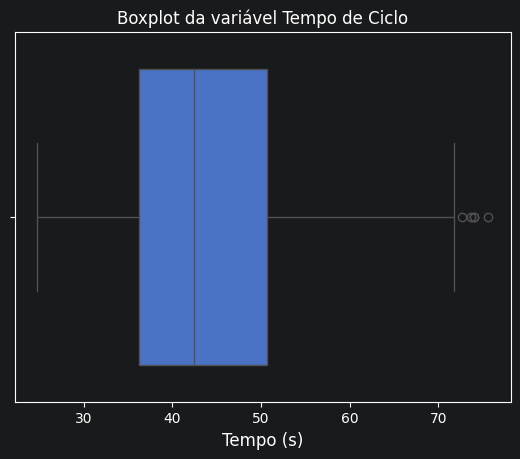

In [31]:
sns.boxplot(data=df.Tempo_Ciclo_s, orient="h")
plt.xlabel('Tempo (s)',fontsize=12)
plt.title('Boxplot da variável Tempo de Ciclo',fontsize=12)
plt.show()

### **Boxplot Comparativo**

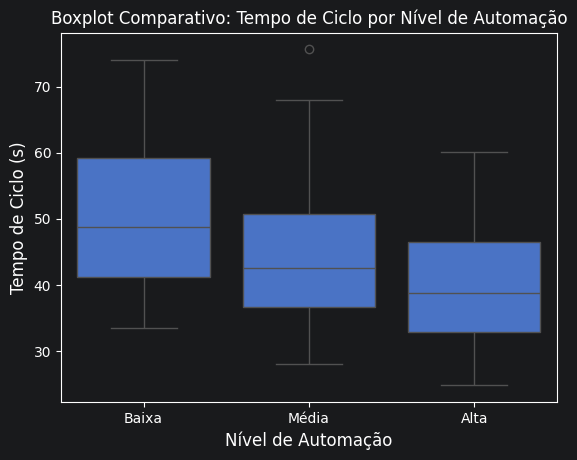

In [35]:
# Ordenando os níveis de automação para exibição correta no boxplot
ordem_automacao = pd.CategoricalDtype(categories=['Baixa', 'Média', 'Alta'], ordered=True)
df['Nivel_Automacao'] = df['Nivel_Automacao'].astype(ordem_automacao)

sns.boxplot(data=df, x='Nivel_Automacao', y='Tempo_Ciclo_s', order=['Baixa', 'Média', 'Alta'])
plt.xlabel('Nível de Automação', fontsize=12)
plt.ylabel('Tempo de Ciclo (s)', fontsize=12)
plt.title('Boxplot Comparativo: Tempo de Ciclo por Nível de Automação', fontsize=12)
plt.show()

In [37]:
# Medidas por categoria (filtragem booleana, sem groupby)
mediana_baixa = df[df.Nivel_Automacao=='Baixa'].Tempo_Ciclo_s.median().round(3)
mediana_media = df[df.Nivel_Automacao=='Média'].Tempo_Ciclo_s.median().round(3)
mediana_alta  = df[df.Nivel_Automacao=='Alta'].Tempo_Ciclo_s.median().round(3)

Q1_baixa = df[df.Nivel_Automacao=='Baixa'].Tempo_Ciclo_s.quantile(q=0.25)
Q3_baixa = df[df.Nivel_Automacao=='Baixa'].Tempo_Ciclo_s.quantile(q=0.75)
IQR_baixa = (Q3_baixa - Q1_baixa).round(3)

Q1_media = df[df.Nivel_Automacao=='Média'].Tempo_Ciclo_s.quantile(q=0.25)
Q3_media = df[df.Nivel_Automacao=='Média'].Tempo_Ciclo_s.quantile(q=0.75)
IQR_media = (Q3_media - Q1_media).round(3)

Q1_alta = df[df.Nivel_Automacao=='Alta'].Tempo_Ciclo_s.quantile(q=0.25)
Q3_alta = df[df.Nivel_Automacao=='Alta'].Tempo_Ciclo_s.quantile(q=0.75)
IQR_alta = (Q3_alta - Q1_alta).round(3)

print(f'Mediana (segundos) -> Baixa: {mediana_baixa} | Média: {mediana_media} | Alta: {mediana_alta}')
print(f'IQR (segundos) -> Baixa: {IQR_baixa} | Média: {IQR_media} | Alta: {IQR_alta}')

Mediana (segundos) -> Baixa: 48.77 | Média: 42.51 | Alta: 38.69
IQR (segundos) -> Baixa: 17.995 | Média: 14.02 | Alta: 13.535


#### **Interpretação do boxplot comparativo**

- **Mediana decrescente:** o tempo de ciclo mediano cai de **48,77 s** (Baixa automação) para **42,51 s** (Média) e **38,69 s** (Alta) — quanto maior o nível de automação, mais rápido é o ciclo de produção.
- **Dispersão também decrescente:** o IQR acompanha essa tendência (17,99 s → 14,02 s → 13,54 s), mostrando que linhas com Alta automação não são só mais rápidas, mas também mais consistentes entre ciclos.

### **Cálculo de Outlier**

In [32]:
# Calculando os limites superiores e inferiores de outliers
linf = Q1 - 1.5*AIQ
lsup = Q3 + 1.5*AIQ

# Resumo e quantidade de outliers
outliers_superiores = df[df.Tempo_Ciclo_s> lsup]
outliers_inferiores = df[df.Tempo_Ciclo_s< linf]

print(f'Limite inferior de outlier = {linf.round(3)}')
print(f'Limite superior de outlier = {lsup.round(3)}')
print(f'Total de outliers: {len(outliers_superiores)+len(outliers_inferiores)}')
print(f'Total de outliers superiores: {len(outliers_superiores)}')
print(f'Total de outliers inferiores: {len(outliers_inferiores)}')

Limite inferior de outlier = 14.622
Limite superior de outlier = 72.318
Total de outliers: 5
Total de outliers superiores: 5
Total de outliers inferiores: 0


#### **Interpretação da assimetria**

A mediana (**Q2 = 42,385 s**) está mais próxima de **Q1 (36,258 s)** do que de **Q3 (50,682 s)**, e todos os **5 outliers** identificados estão acima do **limite superior** — nenhum abaixo do inferior.

Isso indica uma distribuição com **leve assimetria positiva** (cauda mais longa à direita), o que também é visível no boxplot pelo limite superior sendo maior que o inferior.

### Calculando e encontrando a variabilidade dos dados (desvio padrão + variação)

In [33]:
desvio_padrao = df.Tempo_Ciclo_s.std().round(3)
media = df.Tempo_Ciclo_s.mean().round(3)
coeficiente_de_variacao = (desvio_padrao / media * 100).round(2)

print(f'Desvio padrão (Tempo_Ciclo_s) = {desvio_padrao} segundos')
print(f'Média geral dos dados (Valor Médio): {media} segundos')
print(f'Coeficiente de variação dos dados: {coeficiente_de_variacao} %')

Desvio padrão (Tempo_Ciclo_s) = 9.903 segundos
Média geral dos dados (Valor Médio): 44.029 segundos
Coeficiente de variação dos dados: 22.49 %


#### **Interpretação da variabilidade**

O tempo de ciclo apresenta desvio padrão de **9,903 segundos** e coeficiente de variação de **~22,49%** em relação à média de 44,029 s — uma dispersão relativa moderada.